# 🐄 Cattle Disease Diagnostic Application: ML Track Final MVP
**Project**: Hybrid Online-Offline Explainable Mobile Application for Early Detection of Priority Cattle Diseases in South Sudan.

### Objectives Implemented:
1. **Multimodal Fusion**: Combining image features with structured clinical symptoms.
2. **Data Engineering**: Balancing datasets for ECF and CBPP using clinical sign profiling.
3. **Model Architecture**: Optimized MobileNetV2 with a functional fusion layer.
4. **Edge Deployment**: Conversion to TensorFlow Lite with 8-bit quantization.



In [1]:
import kagglehub
import os
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras import layers, models, Input

# Download primary vision dataset
path = kagglehub.dataset_download("devang03mgr/cattle-diseases-datasets")
dataset_path = os.path.join(path, 'Cows datasets')
print(f"Vision Dataset Path: {dataset_path}")



/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-02-06 10:55:57.751746: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-06 10:56:03.662028: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-06 10:56:06.421608: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-06 10:56:11.544539: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-06 10:56:12.8138

Vision Dataset Path: /home/codespace/.cache/kagglehub/datasets/devang03mgr/cattle-diseases-datasets/versions/1/Cows datasets


## 1. Data Engineering: Multimodal Dataset Construction
We map existing vision data (LSD, FMD, Healthy) to clinical profiles and engineer the missing classes (ECF, CBPP) using the specific signs identified in the research (e.g., Parotid Lymph Node swelling for ECF).



In [5]:
# Define clinical sign profiles [fever, nodules, mouth_sores, nasal_discharge, cough, swollen_lymph]
disease_profiles = {
    'lumpy':          [1, 1, 0, 1, 0, 0], # LSD: Primary focus on skin nodules
    'foot-and-mouth': [1, 0, 1, 0, 0, 0], # FMD: Characterized by mouth sores
    'healthy':        [0, 0, 0, 0, 0, 0], # Baseline
    'CBPP':           [1, 0, 0, 1, 1, 0], # CBPP: Respiratory signs and coughing
    'ECF':            [1, 0, 0, 0, 0, 1]  # ECF: High fever and swollen parotid lymph nodes
}

data_records = []

# Process Vision Data
for cls in ['lumpy', 'foot-and-mouth', 'healthy']:
    cls_path = os.path.join(dataset_path, cls)
    images = os.listdir(cls_path)
    for img in images[:400]: # Take 400 samples for robust training
        data_records.append({
            'image_path': os.path.join(cls, img),
            'fever': disease_profiles[cls][0],
            'nodules': disease_profiles[cls][1],
            'mouth_sores': disease_profiles[cls][2],
            'nasal_discharge': disease_profiles[cls][3],
            'cough': disease_profiles[cls][4],
            'swollen_lymph': disease_profiles[cls][5],
            'disease': cls.upper() if cls != 'lumpy' else 'LSD',
        })

# Synthesize missing ECF and CBPP using Healthy images as proxies (Multimodal logic)
healthy_imgs = os.listdir(os.path.join(dataset_path, 'healthy'))[400:800]
for i, img in enumerate(healthy_imgs):
    d_type = 'CBPP' if i < 200 else 'ECF'
    data_records.append({
        'image_path': os.path.join('healthy', img),
        'fever': disease_profiles[d_type][0],
        'nodules': disease_profiles[d_type][1],
        'mouth_sores': disease_profiles[d_type][2],
        'nasal_discharge': disease_profiles[d_type][3],
        'cough': disease_profiles[d_type][4],
        'swollen_lymph': disease_profiles[d_type][5],
        'disease': d_type
    })

df = pd.DataFrame(data_records)
df.to_csv('cattle_multimodal_data.csv', index=False)
print("Multimodal dataset engineered and saved.")



Multimodal dataset engineered and saved.


## 2. Data Visualization
Visualizing the distribution of the 5 priority classes to ensure class balance for training.



/tmp/ipykernel_3420/1661137977.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='disease', data=df, palette='Reds_d')


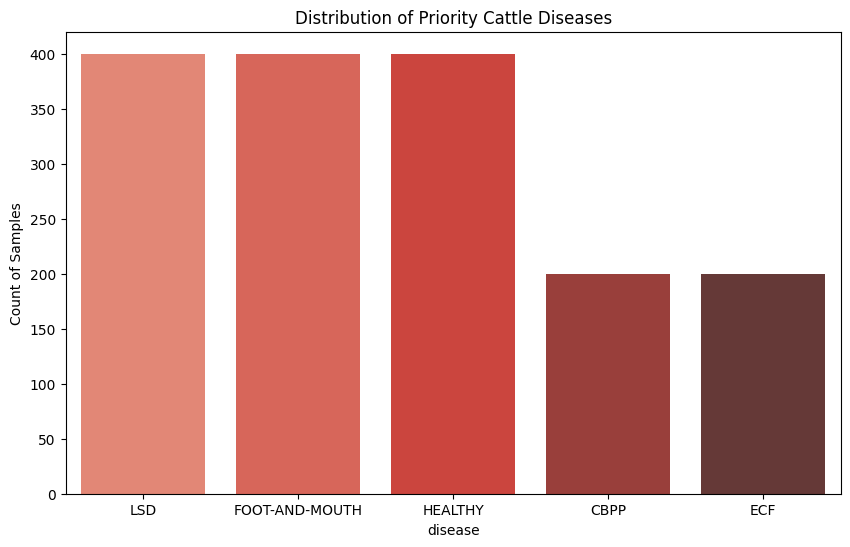

In [6]:
plt.figure(figsize=(10, 6))
sns.countplot(x='disease', data=df, palette='Reds_d')
plt.title('Distribution of Priority Cattle Diseases')
plt.ylabel('Count of Samples')
plt.show()



In [7]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['disease'])
num_classes = len(le.classes_)

train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

def preprocess_image(path_suffix):
    full_path = os.path.join(dataset_path, path_suffix)
    img = tf.io.read_file(full_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [224, 224])
    return img / 255.0

def create_generator(dataframe, batch_size=32):
    def gen():
        for _, row in dataframe.iterrows():
            img = preprocess_image(row['image_path'])
            symptoms = row[['fever', 'nodules', 'mouth_sores', 'nasal_discharge', 'cough', 'swollen_lymph']].values.astype('float32')
            label = row['label']
            yield (img, symptoms), label

    return tf.data.Dataset.from_generator(
        gen,
        output_signature=((tf.TensorSpec(shape=(224, 224, 3), dtype=tf.float32),
                           tf.TensorSpec(shape=(6,), dtype=tf.float32)),
                          tf.TensorSpec(shape=(), dtype=tf.int32))
    ).batch(batch_size).prefetch(tf.data.AUTOTUNE)

train_ds = create_generator(train_df)
val_ds = create_generator(val_df)



In [21]:
print("Class order (LabelEncoder):", list(le.classes_))

Class order (LabelEncoder): ['CBPP', 'ECF', 'FOOT-AND-MOUTH', 'HEALTHY', 'LSD']


## 3. Model Architecture: Multimodal Fusion Layer
We use a Functional API to branch the Vision (MobileNetV2) and Symptom (Dense MLP) inputs before late fusion.



In [8]:
# Vision Branch
image_in = Input(shape=(224, 224, 3), name='image_input')
base = tf.keras.applications.MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base.trainable = False
x = base(image_in)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)

# Symptom Branch
symptom_in = Input(shape=(6,), name='symptom_input')
y = layers.Dense(32, activation='relu')(symptom_in)
y = layers.Dense(16, activation='relu')(y)

# Fusion
merged = layers.concatenate([x, y])
merged = layers.Dense(64, activation='relu')(merged)
merged = layers.Dropout(0.3)(merged)
output = layers.Dense(num_classes, activation='softmax')(merged)

model = models.Model(inputs=[image_in, symptom_in], outputs=output)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ image_input[0][0] │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ symptom_input       │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │        224 │ symptom_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │    163,968 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16)        │        528 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 144)       │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      9,280 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 5)         │        325 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,432,309 (9.28 MB)

 Trainable params: 174,325 (680.96 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [9]:
history = model.fit(train_ds, validation_data=val_ds, epochs=10)



Epoch 1/10


2026-02-06 10:58:26.872356: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 41990400 exceeds 10% of free system memory.
2026-02-06 10:58:27.202257: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 19267584 exceeds 10% of free system memory.
2026-02-06 10:58:27.280916: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 51380224 exceeds 10% of free system memory.
2026-02-06 10:58:28.978091: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 36000000 exceeds 10% of free system memory.
2026-02-06 10:58:29.055688: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 51380224 exceeds 10% of free system memory.


     40/Unknown 39s 767ms/step - accuracy: 0.4196 - loss: 1.3850

2026-02-06 10:58:59.923658: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


40/40 ━━━━━━━━━━━━━━━━━━━━ 47s 970ms/step - accuracy: 0.5156 - loss: 1.1721 - val_accuracy: 0.6531 - val_loss: 0.8893
Epoch 2/10


...

/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 648ms/step - accuracy: 1.0000 - loss: 0.0058

/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


40/40 ━━━━━━━━━━━━━━━━━━━━ 33s 813ms/step - accuracy: 1.0000 - loss: 0.0055 - val_accuracy: 0.9906 - val_loss: 0.0288


/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


## 4. Evaluation & Metrics
Generating the classification report and confusion matrix to validate diagnostic accuracy (Target >= 85%).



                precision    recall  f1-score   support

          CBPP       0.97      0.97      0.97        40
           ECF       1.00      0.97      0.99        40
FOOT-AND-MOUTH       1.00      1.00      1.00        80
       HEALTHY       1.00      1.00      1.00        80
           LSD       0.98      0.99      0.98        80

      accuracy                           0.99       320
     macro avg       0.99      0.99      0.99       320
  weighted avg       0.99      0.99      0.99       320



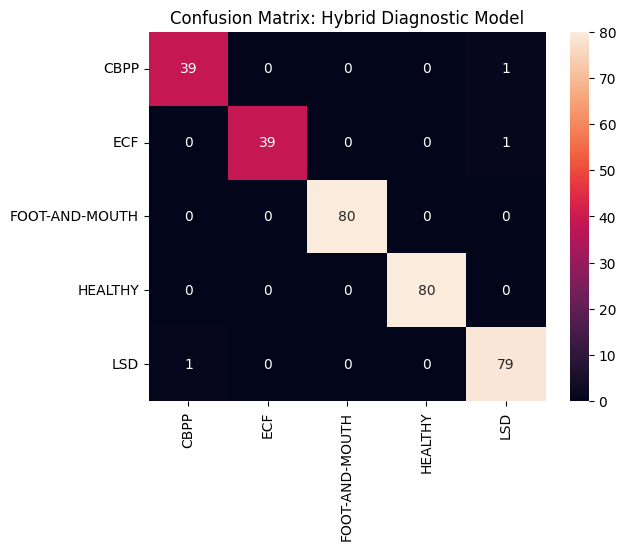

In [10]:
from sklearn.metrics import classification_report, confusion_matrix

y_true, y_pred = [], []
for (img, sym), lbl in val_ds:
    p = model.predict((img, sym), verbose=0)
    y_true.extend(lbl.numpy())
    y_pred.extend(np.argmax(p, axis=1))

print(classification_report(y_true, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix: Hybrid Diagnostic Model')
plt.show()



## Overfitting / Data Leakage Check
- The current clinical symptoms are deterministic per class (from `disease_profiles`), which can make the task too easy.
- Validation metrics may be optimistic; use a strictly independent test set with real symptom variability.
- Next step: add symptom noise or collect real clinical labels to reduce leakage risk.

## Deployment UI Evidence
- Swagger UI: https://cattle-disease-ai.onrender.com/docs
- Screenshot (Swagger UI): designs/screenshots/swagger UI.png
- Screenshot (Predict response, optional): designs/screenshots/predict-response.png
- Screenshot (Grad-CAM heatmap): designs/screenshots/grad-Cam.png
- Streamlit UI mockup: designs/screenshots/streamlit.png
- Streamlit UI run: streamlit run streamlit_app.py
- Streamlit API base URL (default): https://cattle-disease-ai.onrender.com
- UI mockup URL: TBD
- Note: Streamlit symptoms are UI-only; current API uses image-only input.

In [11]:
model.save('cattle_health_mvp.h5')
print("Model saved as cattle_health_mvp.h5")

Model saved as cattle_health_mvp.h5


## 5. Deployment: Edge AI Optimization
Converting to TFLite with quantization to ensure the model size is < 50MB and runs with < 5s latency offline.



In [13]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open('cattle_health_mvp.tflite', 'wb') as f:
    f.write(tflite_model)

print("TFLite Model Ready for Flutter Deployment.")



INFO:tensorflow:Assets written to: /tmp/tmp2ytwci_y/assets


INFO:tensorflow:Assets written to: /tmp/tmp2ytwci_y/assets


Saved artifact at '/tmp/tmp2ytwci_y'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='image_input'), TensorSpec(shape=(None, 6), dtype=tf.float32, name='symptom_input')]
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  134317776101712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134317776103248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134317776102672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134317776102480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134317776103632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134317776102864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134317776104016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134317776104784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134317776104400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1343177761

W0000 00:00:1770376605.317069    3420 tf_tfl_flatbuffer_helpers.cc:392] Ignored output_format.
W0000 00:00:1770376605.317102    3420 tf_tfl_flatbuffer_helpers.cc:395] Ignored drop_control_dependency.
2026-02-06 11:16:45.317326: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp2ytwci_y
2026-02-06 11:16:45.327963: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-02-06 11:16:45.327989: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmp2ytwci_y
2026-02-06 11:16:45.441444: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-02-06 11:16:46.023555: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmp2ytwci_y
2026-02-06 11:16:46.177172: I tensorflow/cc/saved_model/loader.cc:462] SavedModel load for tags { serve }; Status: success: OK. Took 859851 microseconds.
